In [27]:
import xarray as xr
import os
import glob
import numpy as np
import warnings
import matplotlib.pyplot as plt
import sys
import cmocean

warnings.filterwarnings("ignore")
sys.path.append('../src')
sys.path.append('../src-double-gyre')
from plot_helpers import create_animation_ffmpeg, default_rcParams

%load_ext autoreload
%autoreload 3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# First recompute standard loss function

In [2]:
interfaces = xr.open_mfdataset('/scratch/pp2681/mom6/Feb2022/filtered/R32_R2_FGR3/output/prog_full.nc', decode_times=False).e.sortby('Time').sel(Time=slice(365*10,None)).isel(zi=slice(0,-1)).astype('float64')

In [3]:
dataset = xr.Dataset()
dataset['e_mean'] = interfaces.mean('Time')
dataset['e_std'] = interfaces.std('Time')

In [28]:
from helpers.collection_of_experiments import CollectionOfExperiments
ds = CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/filtered', additional_subfolder='output')
ds += CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/bare', additional_subfolder='output')

In [5]:
# Units are petajoules
KE_coarse = ds['R32_R2_FGR3'].KE_joul_series.sel(Time=slice(365*10,None)).compute() * 1e-15
APE_coarse = xr.concat([ds['R32_R2_FGR3'].PE_ssh_series.drop_vars(['zi', 'zl']), ds['R32_R2_FGR3'].PE_joul_series], dim='zi').sel(Time=slice(365*10,None)).compute() * 1e-15

In [6]:
dataset['KE_mean'] = KE_coarse.mean('Time')
dataset['APE_mean'] = APE_coarse.mean('Time')

dataset['KE_std'] = KE_coarse.std('Time')
dataset['APE_std'] = APE_coarse.std('Time')

In [7]:
mask = (dataset.e_std>0.0001)

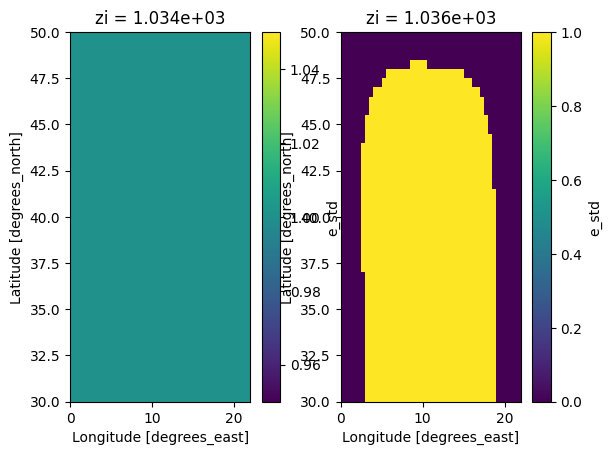

In [8]:
plt.subplot(1,2,1)
mask[0].plot()
plt.subplot(1,2,2)
mask[1].plot()

In [9]:
# The resulting loss for the energetics is
# (KE-KE_true)**2/KE_true**2
# layerwise
for variable in ['KE_mean', 'KE_std', 'APE_mean', 'APE_std']:
    dataset[f'{variable}_var_loss'] = dataset[variable]**2

In [10]:
# For 2D fields we normalize by their l2 norm squared. That way, the normalization constant will grow with the number of grid points, preveting total dominance of 2d fields
ssh_mean_var_loss = (dataset.e_mean.isel(zi=0)**2).sum()
ssh_std_var_loss  = (dataset.e_std.isel(zi=0)**2).sum()

# For internal interface, we sum only over degrees of freedom that are not topography and centered to 1000., which is the resting position of the interface
interface_mean_var_loss = ((dataset.e_mean.isel(zi=1)+1000.)**2).where(mask.isel(zi=1)).sum()
interface_std_var_loss  = ((dataset.e_std.isel(zi=1))**2).sum()

In [11]:
dataset['e_mean_var_loss'] = xr.concat([ssh_mean_var_loss, interface_mean_var_loss], dim='zi') + 0*dataset['e_mean']
dataset['e_std_var_loss']  = xr.concat([ssh_std_var_loss, interface_std_var_loss], dim='zi') + 0*dataset['e_std']

In [12]:
dataset.astype('float32').to_netcdf('../scripts/R32/R2_FGR3_PCA_variability.nc')

In [13]:
test = xr.open_dataset('../scripts/R32/R2_FGR3_series_loss.nc')

In [14]:
for key in dataset.variables:
    error = test[key] - dataset[key]
    error = float(np.abs(error).max() / np.abs(test[key]).max())
    nans = float(np.isnan(dataset[key]).sum())
    print(key, error, nans)

yh 0.0 0.0
xh 0.0 0.0
zi 0.0 0.0
e_mean 1.8142673874512705e-07 0.0
e_std 7.101172798296133e-07 0.0
zl 0.0 0.0
KE_mean 2.2151005926060303e-08 0.0
APE_mean 4.496876838520435e-08 0.0
KE_std 3.077669747690202e-08 0.0
APE_std 1.7317063134148147e-08 0.0
KE_mean_var_loss 8.547225712571133e-09 0.0
KE_std_var_loss 9.134096292480687e-09 0.0
APE_mean_var_loss 3.932901837001665e-09 0.0
APE_std_var_loss 1.8250081043718203e-08 0.0
e_mean_var_loss 2.322329883115716e-09 0.0
e_std_var_loss 7.22531062321788e-08 0.0


# Analysis of PCAs

In [ ]:
1

In [29]:
# Here we perform scaling of both the magnitude and also center data
# Magnitude is scaled for simplicity by the ratio of reduced gravities so we can easily work
# with each interface individually
interfaces = ds['R32_R2_FGR3'].prog.e.sel(Time=slice(365*10,None)).isel(zi=slice(0,-1)).compute().astype('float64')
interfaces_scaled = ((interfaces - interfaces.mean('Time')) / xr.DataArray([1, 100], dims='zi')).compute()

In [30]:
%time ds +=  CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_mean_only_scaling', additional_subfolder='output', prefix='R2_FGR3_mean_only_scaling')

CPU times: user 62.8 ms, sys: 130 ms, total: 193 ms
Wall time: 2.45 s


In [31]:
%time ds +=  CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_PCA_variability', additional_subfolder='output', prefix='R2_FGR3_PCA_variability')

CPU times: user 56.5 ms, sys: 166 ms, total: 223 ms
Wall time: 2.98 s


In [47]:
interfaces = ds['R2_FGR3_mean_only_scaling-iteration-05-ensemble_mean'].prog.e.sel(Time=slice(365*10,None)).isel(zi=slice(0,-1)).compute().astype('float64')
interfaces_parameterized_scaled = ((interfaces - interfaces.mean('Time')) / xr.DataArray([1, 100], dims='zi')).compute()

In [34]:
def plot(idx=0):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    interfaces_parameterized_scaled.isel(zi=0,Time=idx).plot(vmin=-1, extend='both')
    plt.title('Upper interface anomaly')
    plt.subplot(1,2,2)
    interfaces_parameterized_scaled.isel(zi=1,Time=idx).plot(vmin=-1, extend='both')
    plt.title("Lower interface anomaly (divided by $g/g'=100$)")
    Time = int(interfaces_scaled.isel(Time=idx).Time)
    plt.suptitle(f'{Time} day')

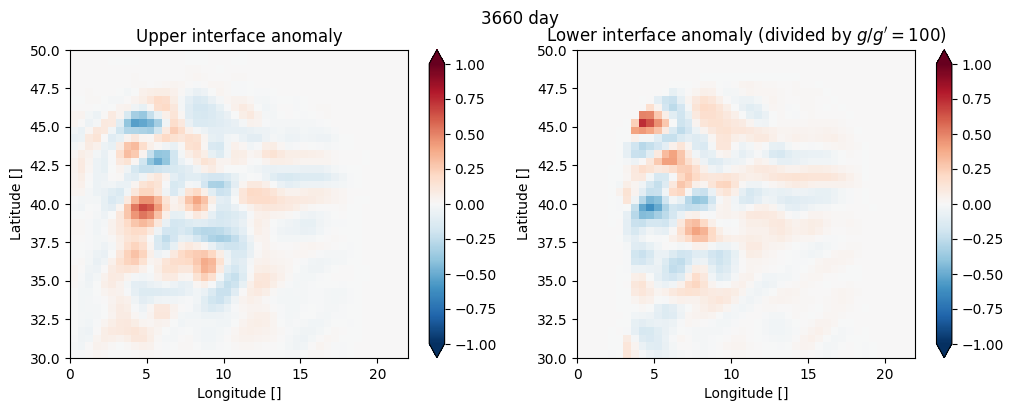

In [35]:
plot()

In [36]:
create_animation_ffmpeg(plot, idx=range(0,100), filename='interface_variability_PCA_variability.mp4', FPS=12)

Savefig .ffmpeg/interface_variability_PCA_variability/frame-0.png
Savefig .ffmpeg/interface_variability_PCA_variability/frame-1.png
Savefig .ffmpeg/interface_variability_PCA_variability/frame-2.png
Savefig .ffmpeg/interface_variability_PCA_variability/frame-3.png
Savefig .ffmpeg/interface_variability_PCA_variability/frame-4.png
Savefig .ffmpeg/interface_variability_PCA_variability/frame-5.png
Savefig .ffmpeg/interface_variability_PCA_variability/frame-6.png
Savefig .ffmpeg/interface_variability_PCA_variability/frame-7.png
Savefig .ffmpeg/interface_variability_PCA_variability/frame-8.png
Savefig .ffmpeg/interface_variability_PCA_variability/frame-9.png
Savefig .ffmpeg/interface_variability_PCA_variability/frame-10.png
Savefig .ffmpeg/interface_variability_PCA_variability/frame-11.png
Savefig .ffmpeg/interface_variability_PCA_variability/frame-12.png
Savefig .ffmpeg/interface_variability_PCA_variability/frame-13.png
Savefig .ffmpeg/interface_variability_PCA_variability/frame-14.png
Savef

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

# Capturing interface variance in basis of PCAs. Two cases: hires and parameterized in the same basis

In [48]:
interfaces_scaled.shape

(1095, 2, 40, 44)

In [49]:
Nt = interfaces_scaled.shape[0]

In [50]:
X_true = interfaces_scaled.values.reshape(Nt,-1)

In [51]:
X_true.shape

(1095, 3520)

In [52]:
svd_true = np.linalg.svd(X_true, full_matrices=False)

In [30]:
print(svd_true.U.shape)
print(svd_true.S.shape)
print(svd_true.Vh.shape)

(1095, 1095)
(1095,)
(1095, 3520)


In [31]:
# Check SVD error
np.abs((X_true - svd_true.U @ np.diag(svd_true.S) @ svd_true.Vh)).max() / np.abs((X_true)).max()

9.65921816417679e-15

Text(0.5, 0.98, 'EOF 1')

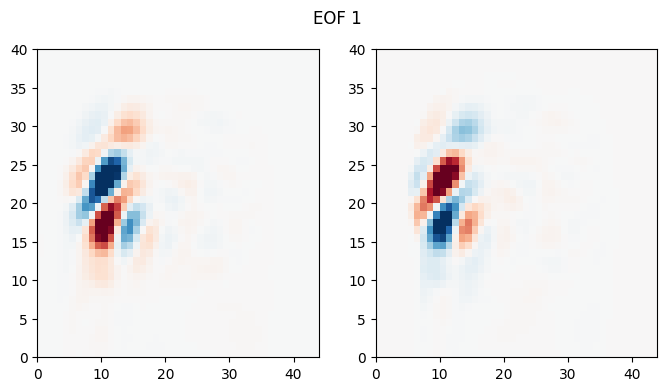

In [15]:
eof = svd_true.Vh[0].reshape(2,40,44)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.pcolormesh(eof[0],cmap='RdBu_r',vmin=-0.1,vmax=0.1)

plt.subplot(1,2,2)
plt.pcolormesh(eof[1],cmap='RdBu_r',vmin=-0.1,vmax=0.1)
plt.suptitle('EOF 1')

Text(0.5, 0.98, 'EOF 2')

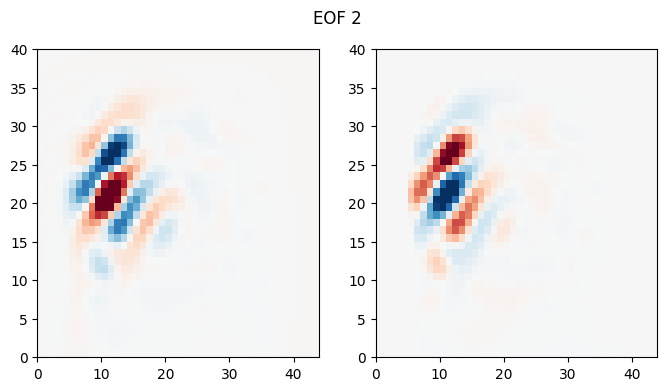

In [16]:
eof = svd_true.Vh[1].reshape(2,40,44)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.pcolormesh(eof[0],cmap='RdBu_r',vmin=-0.1,vmax=0.1)

plt.subplot(1,2,2)
plt.pcolormesh(eof[1],cmap='RdBu_r',vmin=-0.1,vmax=0.1)
plt.suptitle('EOF 2')

Text(0.5, 0.98, 'EOF 3')

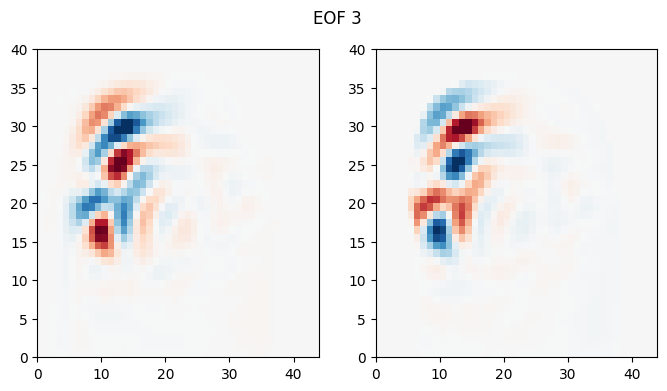

In [18]:
eof = svd_true.Vh[2].reshape(2,40,44)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.pcolormesh(eof[0],cmap='RdBu_r',vmin=-0.1,vmax=0.1)

plt.subplot(1,2,2)
plt.pcolormesh(eof[1],cmap='RdBu_r',vmin=-0.1,vmax=0.1)
plt.suptitle('EOF 3')

Text(0.5, 0.98, 'EOF 3')

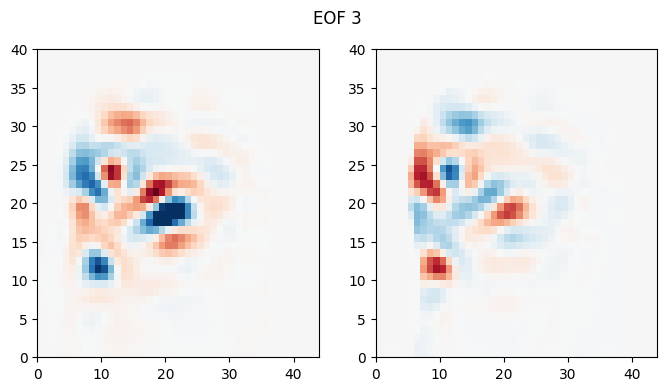

In [65]:
eof = svd_true.Vh[9].reshape(2,40,44)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.pcolormesh(eof[0],cmap='RdBu_r',vmin=-0.1,vmax=0.1)

plt.subplot(1,2,2)
plt.pcolormesh(eof[1],cmap='RdBu_r',vmin=-0.1,vmax=0.1)
plt.suptitle('EOF 10')

Text(0.5, 0.98, 'EOF 20')

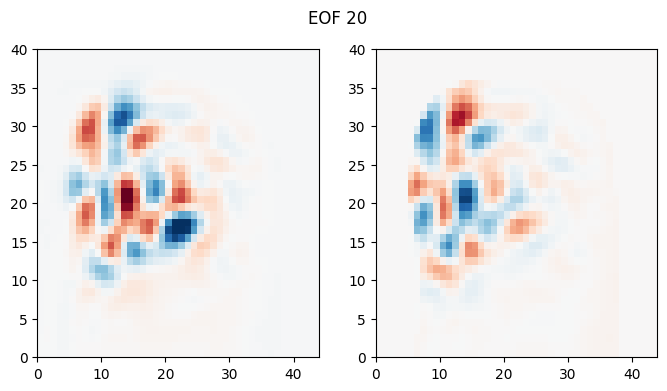

In [66]:
eof = svd_true.Vh[19].reshape(2,40,44)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.pcolormesh(eof[0],cmap='RdBu_r',vmin=-0.1,vmax=0.1)

plt.subplot(1,2,2)
plt.pcolormesh(eof[1],cmap='RdBu_r',vmin=-0.1,vmax=0.1)
plt.suptitle('EOF 20')

Text(0.5, 0.98, 'EOF 100')

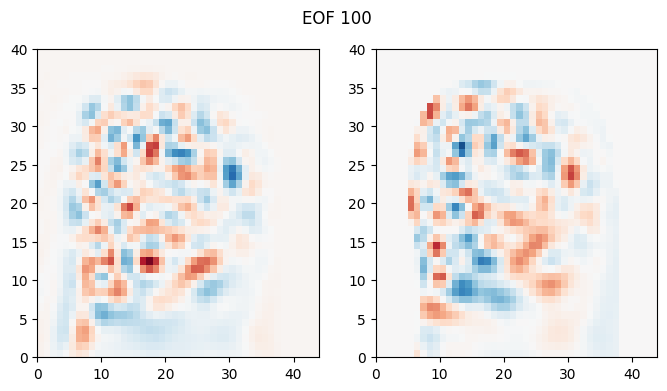

In [67]:
eof = svd_true.Vh[99].reshape(2,40,44)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.pcolormesh(eof[0],cmap='RdBu_r',vmin=-0.1,vmax=0.1)

plt.subplot(1,2,2)
plt.pcolormesh(eof[1],cmap='RdBu_r',vmin=-0.1,vmax=0.1)
plt.suptitle('EOF 100')

Text(0.5, 0.98, 'EOF 200')

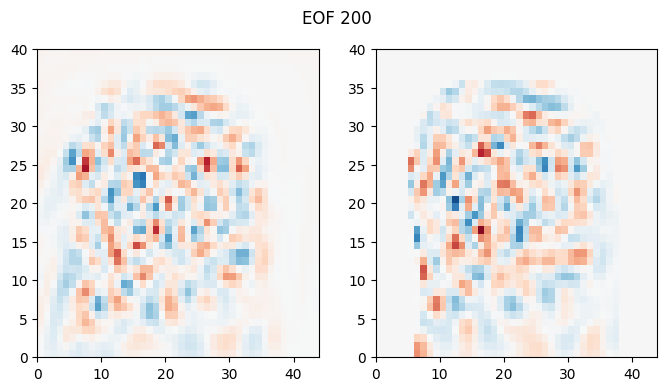

In [68]:
eof = svd_true.Vh[199].reshape(2,40,44)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.pcolormesh(eof[0],cmap='RdBu_r',vmin=-0.1,vmax=0.1)

plt.subplot(1,2,2)
plt.pcolormesh(eof[1],cmap='RdBu_r',vmin=-0.1,vmax=0.1)
plt.suptitle('EOF 200')

Text(0.5, 0.98, 'EOF 500')

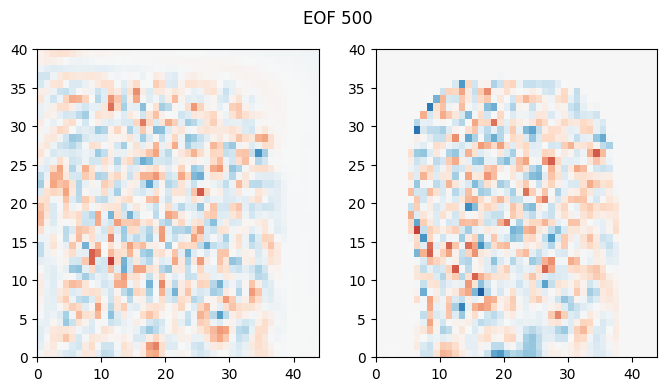

In [69]:
eof = svd_true.Vh[499].reshape(2,40,44)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.pcolormesh(eof[0],cmap='RdBu_r',vmin=-0.1,vmax=0.1)

plt.subplot(1,2,2)
plt.pcolormesh(eof[1],cmap='RdBu_r',vmin=-0.1,vmax=0.1)
plt.suptitle('EOF 500')

# Variance distribution over EOFs
We have the decomposition of the data matrix
$$
X = U \Sigma V^T
$$
The covariance matrix:
$$
C = \frac{1}{N_t} X^T X = \frac{1}{N_t} V \Sigma^2 V^T
$$

Total variance of the signal is:
$$
\langle \sum_{ijk} e_{ijk}'^2 \rangle = \mathrm{tr}(C) = \frac{1}{N_t} \mathrm{tr}(\Sigma^2)
$$

Thus, the variance power spectrum which is independent on the number of time snapshots is
$$
P = \frac{1}{N_t} \mathrm{diag}(\Sigma^2)
$$

In [19]:
# squared second norm over space and mean over time
(X_true**2).sum(axis=1).mean(0)

77.82148904098062

Here we check Parseval identity. Summation of variance of the spatial coordinate should be equal to summation of variance over the EOF number

In [20]:
Power = svd_true.S**2 * 1/Nt
Power.sum()

77.82148904098067

Text(0.5, 0, 'EOF number')

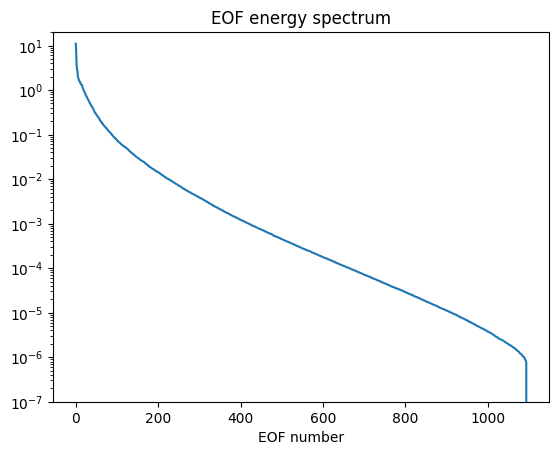

In [21]:
# The last singular value is zero because we removed mean
plt.plot(Power)
plt.yscale('log')
plt.ylim([1e-7,2e+1])
plt.title('EOF energy spectrum')
plt.xlabel('EOF number')

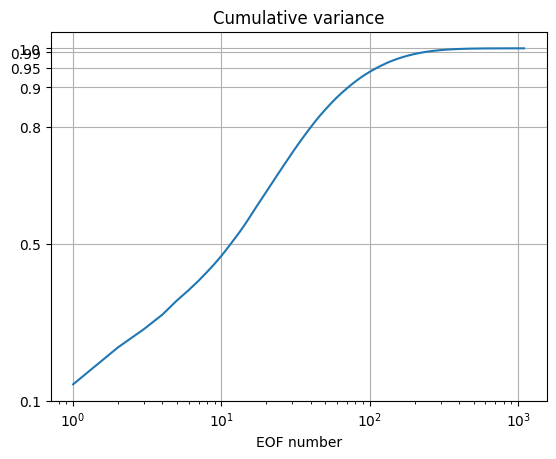

In [22]:
plt.plot(np.arange(1,Nt+1),np.cumsum(Power) / np.sum(Power))
plt.title('Cumulative variance')
plt.xlabel('EOF number')
plt.xscale('log')
plt.yticks([0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0], [0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0])
plt.grid()

# Latest calibrated eANN captures only 60% of variance
Realistically, only 20-ish PCAs is enough to already outperform our baseline

In [23]:
Variance_filtered = (interfaces_scaled**2).sum(['zi','yh','xh']).mean('Time')
Variance_parameterized = (interfaces_parameterized_scaled**2).sum(['zi','yh','xh']).mean('Time')
Variance_parameterized / Variance_filtered

<xarray.DataArray ()> Size: 8B
array(0.58897647)

In [69]:
print(Variance_filtered.values, Variance_parameterized.values)

77.82148904098062 45.83502623475343


# Variance of parameterized model in basis of EOFs of true model
We first start with SVD decomposition of the high-resolution simulation
$$
X_{true} = U_{true} \Sigma_{true} V_{true}^T
$$
Here, matrix $V_{true}^T$ represents a change of basis. We can use this matrix to implement change of basis of the data matrix.
$$
Y_{true} = X_{true} V_{true}
$$
Here, $Y_{true}$ is the new data matrix in transofrmed PCA space with first dimension showing time index, and second dimension showing the number of PCA component
$$
Y_{true} \in \mathbb{R}^{N_t \times N_{\mathrm{PCAs}}}
$$

In [16]:
Y_true = X_true @ svd_true.Vh.T

In [17]:
# Note that by construction number of time snapshots and the number of PCAs are equal
Y_true.shape

(1095, 1095)

Text(0.5, 1.0, 'EOF 3 time series')

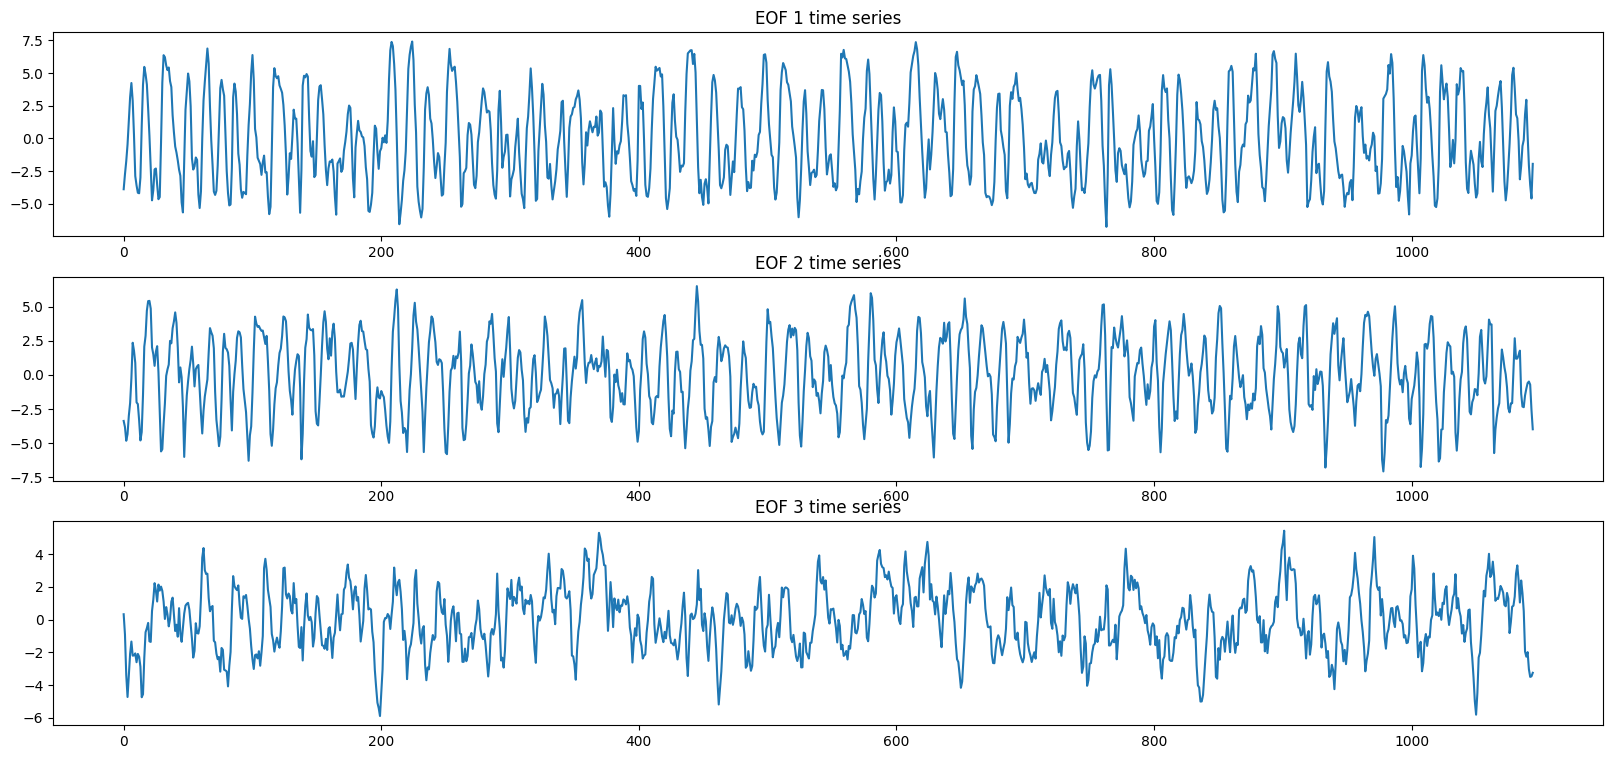

In [48]:
plt.figure(figsize=(20,9))
plt.subplot(3,1,1)
plt.plot(Y_true[:,0])
plt.title('EOF 1 time series')

plt.subplot(3,1,2)
plt.plot(Y_true[:,1])
plt.title('EOF 2 time series')

plt.subplot(3,1,3)
plt.plot(Y_true[:,2])
plt.title('EOF 3 time series')

# EOF timeseries should have variance given by the diagonal of SVD
That is
$$
Var(Y_{true}, axis=Time) = \frac{1}{N_t} \mathrm{diag}(Y_{true}^T Y_{true}) = \frac{1}{N_t} \mathrm{diag}(\Sigma)
$$

In [54]:
np.linalg.norm(Y_true.var(0) - Power)

1.1687723879076928e-14

In [60]:
np.linalg.norm(1/Nt*np.diag(Y_true.T@Y_true) - Power)

1.2031748596990064e-14

# Method to compute power spectrum of parameterized model in spectrum of EOFs of high-resolution simulation
* Convert the data matrix of parameterized model to basis of PCAs of high resolution simulation
$$
Y_{param} = X_{param} V_{true}
$$
* Power spectrum of parameterized model:
$$
P_{param} = \frac{1}{N_t}Y_{param}^TY_{param}
$$

In [53]:
X_param = interfaces_parameterized_scaled.values.reshape(Nt,-1)

In [54]:
Y_param = X_param @ svd_true.Vh.T

In [55]:
Power_param = 1/Nt*np.diag(Y_param.T@Y_param)

In [21]:
svd_param = np.linalg.svd(X_param, full_matrices=False)

In [110]:
# Spatial white noise model for comparison
noise_model = np.random.randn(*X_true.shape) * float(np.sqrt(Variance_filtered) / np.sqrt(X_true.shape[1]))
Y_noise = noise_model @ svd_true.Vh.T
Power_noise = 1/Nt*np.diag(Y_noise.T@Y_noise)

In [111]:
(noise_model**2).sum(1).mean(0)

77.7926682790384

In [112]:
(X_true**2).sum(1).mean(0)

77.82148904098062

# Subsamples of true data to approximately know confidence bounds

In [152]:
Nt_short = 121 # Short trajectory of 10 years
ts = int(np.random.choice(Nt-Nt_short,1)); te = ts + Nt_short
X_true_sample1 = X_true[ts:te]
ts = int(np.random.choice(Nt-Nt_short,1)); te = ts + Nt_short
X_true_sample2 = X_true[ts:te]
ts = int(np.random.choice(Nt-Nt_short,1)); te = ts + Nt_short
X_true_sample3 = X_true[ts:te]

In [153]:
Y_true_sample1 = X_true_sample1 @ svd_true.Vh.T
Y_true_sample2 = X_true_sample2 @ svd_true.Vh.T
Y_true_sample3 = X_true_sample3 @ svd_true.Vh.T

In [154]:
Power_true_sample1 = 1/Nt_short*np.diag(Y_true_sample1.T@Y_true_sample1)
Power_true_sample2 = 1/Nt_short*np.diag(Y_true_sample2.T@Y_true_sample2)
Power_true_sample3 = 1/Nt_short*np.diag(Y_true_sample3.T@Y_true_sample3)

# Basis can be efficiently used to reconstruct full variance of parameterized model

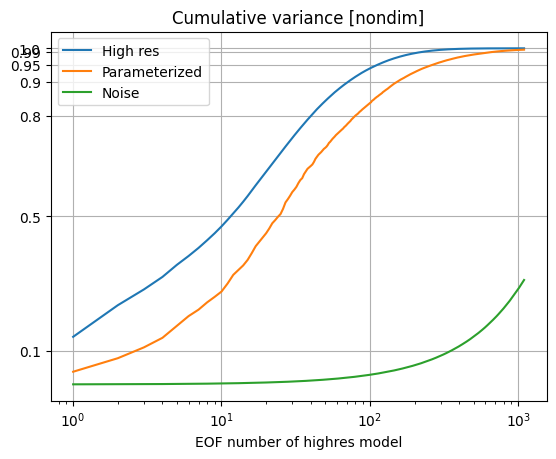

In [115]:
plt.plot(np.arange(1,Nt+1),np.cumsum(Power) / np.sum(Power), label='High res')
plt.plot(np.arange(1,Nt+1),np.cumsum(Power_param) / (X_param**2).sum(1).mean(0), label='Parameterized')
plt.plot(np.arange(1,Nt+1),np.cumsum(Power_noise) / (noise_model**2).sum(1).mean(0), label='Noise')
plt.title('Cumulative variance [nondim]')
plt.xlabel('EOF number of highres model')
plt.xscale('log')
plt.yticks([0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0], [0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0])
plt.grid()
plt.legend()

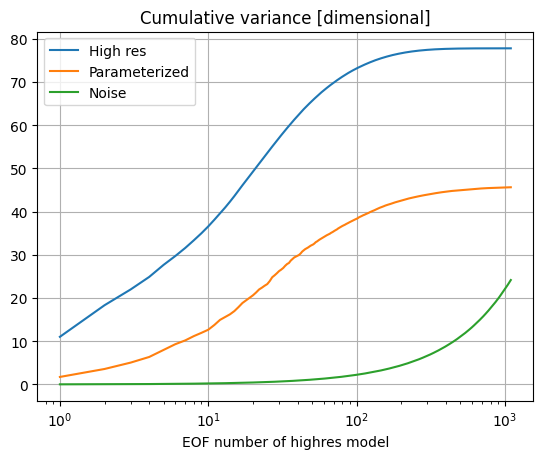

In [117]:
plt.plot(np.arange(1,Nt+1),np.cumsum(Power), label='High res')
plt.plot(np.arange(1,Nt+1),np.cumsum(Power_param), label='Parameterized')
plt.plot(np.arange(1,Nt+1),np.cumsum(Power_noise), label='Noise')
plt.title('Cumulative variance [dimensional]')
plt.xlabel('EOF number of highres model')
plt.xscale('log')
#plt.yticks([0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0], [0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0])
plt.grid()
plt.legend()

Text(0, 0.5, 'Energy per EOF component \nof high-resolution model')

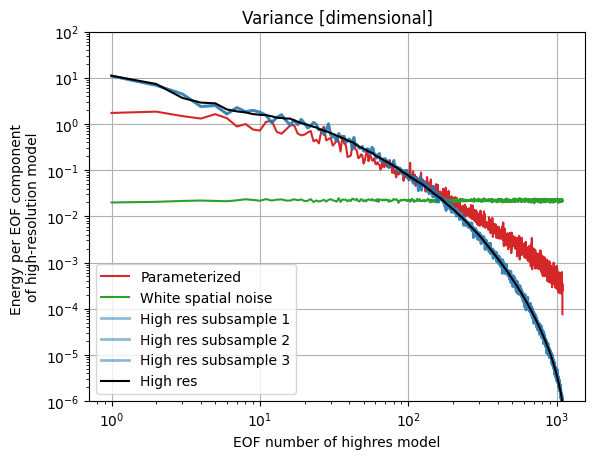

In [159]:
plt.plot(np.arange(1,Nt+1),(Power_param), label='Parameterized', color='tab:red')
plt.plot(np.arange(1,Nt+1),(Power_noise), label='White spatial noise', color='tab:green')
plt.plot(np.arange(1,Nt+1), Power_true_sample3, label='High res subsample 1', color='tab:blue', alpha=0.5, lw=2)
plt.plot(np.arange(1,Nt+1), Power_true_sample3, label='High res subsample 2', color='tab:blue', alpha=0.5, lw=2)
plt.plot(np.arange(1,Nt+1), Power_true_sample3, label='High res subsample 3', color='tab:blue', alpha=0.5, lw=2)
plt.plot(np.arange(1,Nt+1),(Power), label='High res', color='k')
plt.title('Variance [dimensional]')
plt.xlabel('EOF number of highres model')
plt.xscale('log')
#plt.yticks([0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0], [0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0])
plt.grid()
plt.legend()
plt.yscale('log')
plt.ylim([1e-6,1e+2])
plt.ylabel('Energy per EOF component \nof high-resolution model')

In [29]:
Power_param = 1/Nt*np.diag(Y_param.T@Y_param)
Power = 1/Nt*np.diag(Y_true.T@Y_true)

Y_true_in_param = X_true @ svd_param.Vh.T
Y_param_in_param = X_param @ svd_param.Vh.T
Power_true_in_param = 1/Nt*np.diag(Y_true_in_param.T@Y_true_in_param)
Power_param_in_param = 1/Nt*np.diag(Y_param_in_param.T@Y_param_in_param)

Text(0, 0.5, 'Energy per EOF component \nof high-resolution model')

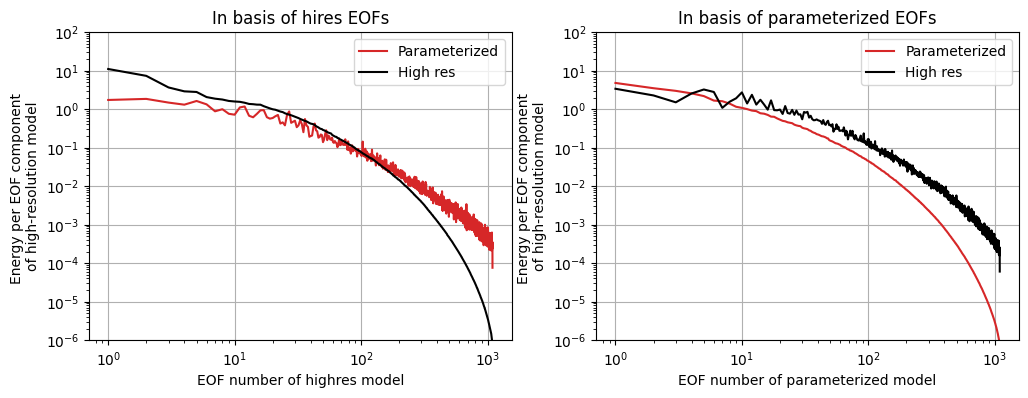

In [32]:
# Energetic EOFs of parameterized model project onto short waves of hires and vice versa.
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(np.arange(1,Nt+1),(Power_param), label='Parameterized', color='tab:red')
plt.plot(np.arange(1,Nt+1),(Power), label='High res', color='k')
plt.title('In basis of hires EOFs')
plt.xlabel('EOF number of highres model')
plt.xscale('log')
#plt.yticks([0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0], [0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0])
plt.grid()
plt.legend()
plt.yscale('log')
plt.ylim([1e-6,1e+2])
plt.ylabel('Energy per EOF component \nof high-resolution model')

plt.subplot(1,2,2)
plt.plot(np.arange(1,Nt+1),(Power_param_in_param), label='Parameterized', color='tab:red')
plt.plot(np.arange(1,Nt+1),(Power_true_in_param), label='High res', color='k')
plt.title('In basis of parameterized EOFs')
plt.xlabel('EOF number of parameterized model')
plt.xscale('log')
#plt.yticks([0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0], [0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0])
plt.grid()
plt.legend()
plt.yscale('log')
plt.ylim([1e-6,1e+2])
plt.ylabel('Energy per EOF component \nof high-resolution model')

In [34]:
cov_true_Y = Y_true.T@Y_true

In [35]:
cov_param_Y = Y_param.T@Y_param

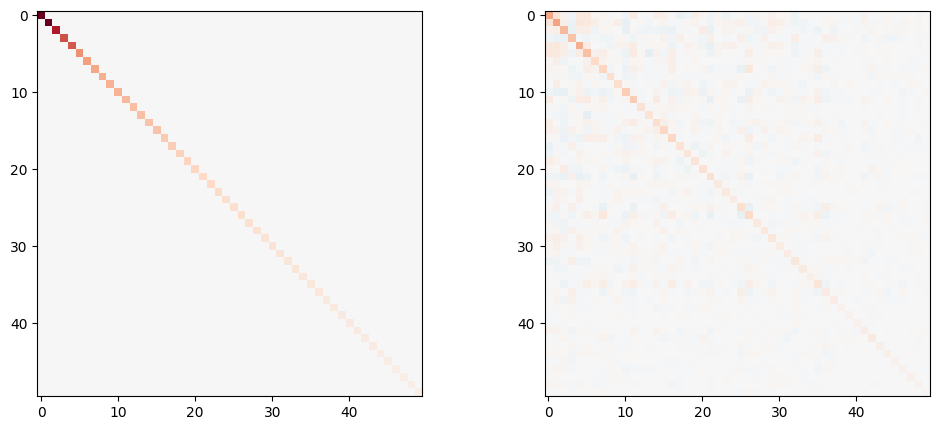

In [56]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(xr.DataArray(cov_true_Y[:50,:50]), vmin=-5000,vmax=5000,cmap='RdBu_r')
plt.subplot(1,2,2)
plt.imshow(xr.DataArray(cov_param_Y[:50,:50]), vmin=-5000,vmax=5000,cmap='RdBu_r')

# Computational of the loss function
* Normalize interfaces according to gravity/reduced gravity.
* This gives normalization constants for e_mean and e_std
* Second metric, apart from e_mean, is the square root of PCA power spectrum.
* The normalization of PCA spectrum should be such that l2 norm of it equals l2 norm of e_std and approximately equal to l2norm of e_mean

In [77]:
g_ratio = xr.DataArray([1., 100.], dims='zi') # Ratio of reduced gravity of upper interface to reduced gravity of lower interface
# Normalization constant is squared because it is variance
dataset['e_mean_var_PCA'] = g_ratio**2 + 0*dataset['e_mean']
dataset['e_std_var_PCA']  = g_ratio**2 + 0*dataset['e_std']

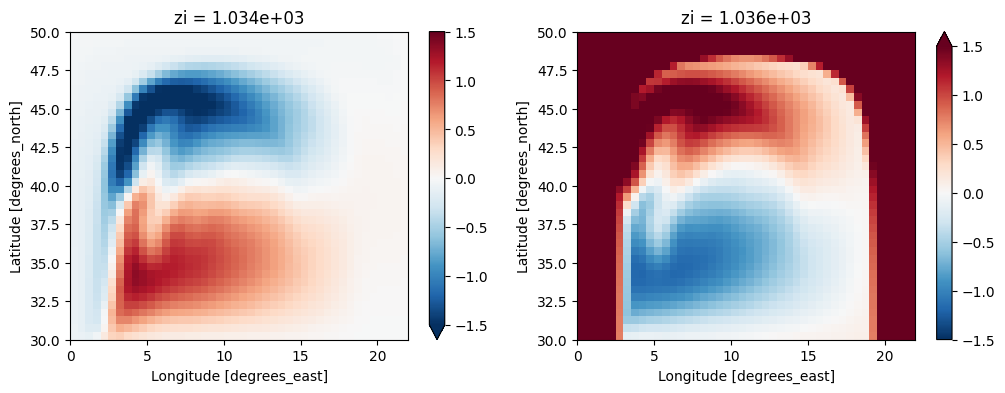

In [78]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
(dataset['e_mean'] / np.sqrt(dataset['e_mean_var_PCA'])).isel(zi=0).plot(vmin=-1.5)
plt.subplot(1,2,2)
((dataset['e_mean'] + 1000.) / np.sqrt(dataset['e_mean_var_PCA'])).isel(zi=1).plot(vmin=-1.5)

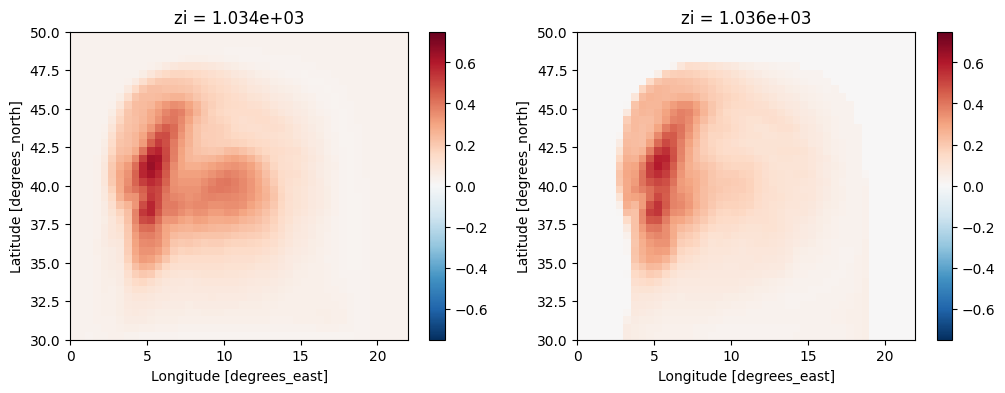

In [145]:
# For simplicity, we can do not engeneer additional normalization coefficient for variability. Although, we can increase the weighting factor twice to approximately match the vlaues
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
(dataset['e_std'] / np.sqrt(dataset['e_std_var_PCA'])).isel(zi=0).plot(vmin=-0.75)
plt.subplot(1,2,2)
((dataset['e_std']) / np.sqrt(dataset['e_std_var_PCA'])).isel(zi=1).plot(vmin=-0.75)

## Computing power spectrum
Note for optimization we store sqrt of PCA power spectrum

In [97]:
interfaces = ds['R32_R2_FGR3'].prog.e.sel(Time=slice(365*10,None)).isel(zi=slice(0,-1)).compute().astype('float64')
interfaces_scaled = ((interfaces - interfaces.mean('Time')) / g_ratio).compute()

In [98]:
Nt = interfaces_scaled.shape[0]
X = interfaces_scaled.values.reshape(Nt,-1)

In [99]:
Y = X @ svd_true.Vh.T

In [100]:
# Variance over the time direction
Power = Y.var(0)

Text(0, 0.5, 'Energy per EOF component \nof high-resolution model')

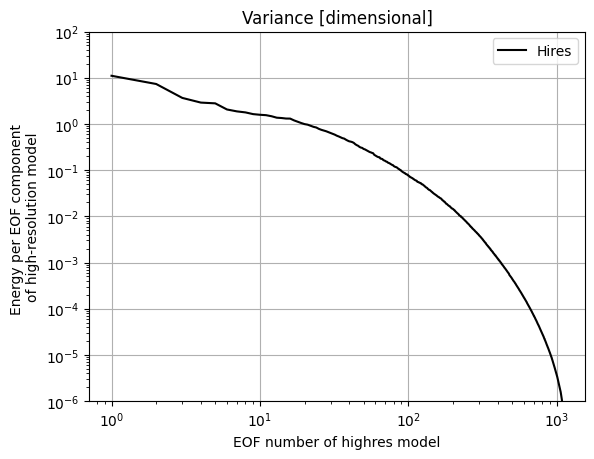

In [101]:
plt.plot(np.arange(1,Nt+1),(Power), label='Hires', color='k')
plt.title('Variance [dimensional]')
plt.xlabel('EOF number of highres model')
plt.xscale('log')
plt.grid()
plt.legend()
plt.yscale('log')
plt.ylim([1e-6,1e+2])
plt.ylabel('Energy per EOF component \nof high-resolution model')

Text(0, 0.5, 'Energy per EOF component \nof high-resolution model')

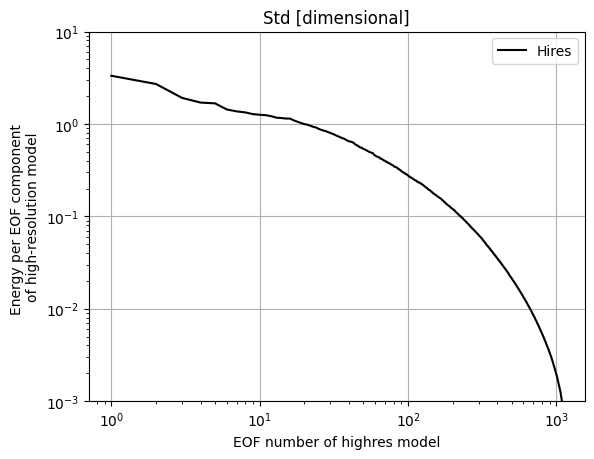

In [102]:
plt.plot(np.arange(1,Nt+1),np.sqrt(Power), label='Hires', color='k')
plt.title('Std [dimensional]')
plt.xlabel('EOF number of highres model')
plt.xscale('log')
plt.grid()
plt.legend()
plt.yscale('log')
plt.ylim([1e-3,1e+1])
plt.ylabel('Energy per EOF component \nof high-resolution model')

In [103]:
np.linalg.norm(Power - svd_true.S**2/Nt)

1.1687723879076928e-14

In [104]:
np.linalg.norm(np.sqrt(Power))

8.821648884476227

In [105]:
normalized_e_std = dataset['e_std'] / np.sqrt(dataset['e_std_var_PCA'])

In [106]:
np.linalg.norm(normalized_e_std)

8.821648884476225

In [107]:
# Comparable to e_mean. Although slightly less as e_mean has more structure
np.linalg.norm(dataset['e_mean'].isel(zi=0))

23.867571751841666

In [108]:
dataset['power_PCA_sqrt'] = xr.DataArray(np.sqrt(Power), dims='PCA')

In [109]:
# Power spectrum is already perfectly normalized. No need to do anything additional. Just use unity
dataset['power_PCA_sqrt_var'] = 1 + 0*dataset['power_PCA_sqrt']

In [120]:
dataset['power_PCA_sqrt'][:50]

<xarray.DataArray 'power_PCA_sqrt' (PCA: 50)> Size: 400B
array([3.31990814, 2.7048443 , 1.91208975, 1.70177995, 1.66989431,
       1.4334574 , 1.36682834, 1.33228795, 1.27689113, 1.25622428,
       1.24388692, 1.21026308, 1.16784456, 1.15841444, 1.143738  ,
       1.14193343, 1.09178489, 1.05508129, 1.0223258 , 0.99551548,
       0.98134857, 0.95447941, 0.92955878, 0.91477905, 0.88339467,
       0.8627407 , 0.8483781 , 0.83261678, 0.81434729, 0.79695983,
       0.78274413, 0.76513526, 0.74552167, 0.73189826, 0.7165635 ,
       0.7016707 , 0.69387877, 0.67546693, 0.66042283, 0.64829836,
       0.64293231, 0.63525747, 0.62289408, 0.60233628, 0.58903557,
       0.57919428, 0.56294667, 0.55458475, 0.54985481, 0.53593147])
Dimensions without coordinates: PCA

In [111]:
dataset['g_ratio'] = g_ratio

In [112]:
dataset['g_ratio']

<xarray.DataArray 'g_ratio' (zi: 2)> Size: 16B
array([  1., 100.])
Coordinates:
  * zi       (zi) float64 16B 1.034e+03 1.036e+03

In [115]:
dataset['PCA_Vh'] = xr.DataArray(svd_true.Vh, dims=['PCA', 'NzNyNx'])

In [118]:
dataset['PCA_Vh']

<xarray.DataArray 'PCA_Vh' (PCA: 1095, NzNyNx: 3520)> Size: 31MB
array([[-0.00015183, -0.00017919, -0.0001974 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.00080121,  0.000702  ,  0.00050239, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.0006625 ,  0.00031776, -0.00031606, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.02861975, -0.02238525, -0.0138986 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.02974546,  0.02867397, -0.00975146, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.01979145,  0.01101777,  0.00014322, ...,  0.        ,
         0.        ,  0.        ]])
Dimensions without coordinates: PCA, NzNyNx

In [117]:
dataset.astype('float32').to_netcdf('../scripts/R32/R2_FGR3_PCA_variability.nc')

In [114]:
svd_true.Vh.shape

(1095, 3520)

In [119]:
dataset

<xarray.Dataset> Size: 31MB
Dimensions:             (yh: 40, xh: 44, zi: 2, zl: 2, PCA: 1095, NzNyNx: 3520)
Coordinates:
  * yh                  (yh) float64 320B 30.25 30.75 31.25 ... 49.25 49.75
  * xh                  (xh) float64 352B 0.25 0.75 1.25 ... 20.75 21.25 21.75
  * zi                  (zi) float64 16B 1.034e+03 1.036e+03
  * zl                  (zl) float64 16B 1.035e+03 1.036e+03
Dimensions without coordinates: PCA, NzNyNx
Data variables: (12/18)
    e_mean              (zi, yh, xh) float64 28kB dask.array<chunksize=(2, 40, 44), meta=np.ndarray>
    e_std               (zi, yh, xh) float64 28kB dask.array<chunksize=(2, 40, 44), meta=np.ndarray>
    KE_mean             (zl) float64 16B 5.441 0.3489
    APE_mean            (zi) float64 16B 0.7337 72.61
    KE_std              (zl) float64 16B 0.4678 0.07651
    APE_std             (zi) float64 16B 0.03465 2.723
    ...                  ...
    e_mean_var_PCA      (zi, yh, xh) float64 28kB dask.array<chunksize=(2, 40, 44), meta=np.ndarray>
    e_std_var_PCA       (zi, yh, xh) float64 28kB dask.array<chunksize=(2, 40, 44), meta=np.ndarray>
    power_PCA_sqrt      (PCA) float64 9kB 3.32 2.705 ... 0.0008791 8.456e-17
    power_PCA_sqrt_var  (PCA) float64 9kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    g_ratio             (zi) float64 16B 1.0 100.0
    PCA_Vh              (PCA, NzNyNx) float64 31MB -0.0001518 -0.0001792 ... 0.0

# Analysis of the loss function

In [235]:
metrics = xr.open_dataset('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_PCA_variability/metrics_00.nc').isel(iter=0).load()

(0.001, 10.0)

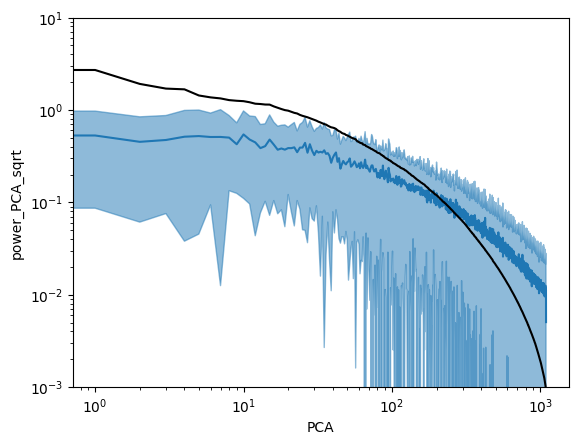

In [236]:
metrics.power_PCA_sqrt.mean('ens').plot()
plt.fill_between(metrics.PCA, metrics.power_PCA_sqrt.mean('ens') - metrics.power_PCA_sqrt.std('ens'),
            metrics.power_PCA_sqrt.mean('ens') + metrics.power_PCA_sqrt.std('ens'), color='tab:blue', alpha=0.5)
dataset.power_PCA_sqrt.plot(color='k')
plt.yscale('log')
plt.xscale('log')
plt.ylim([1e-3,1e+1])

Text(0.5, 0, 'Spatial point')

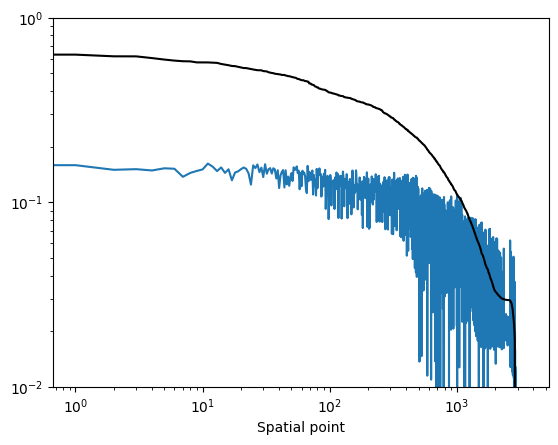

In [237]:
e_std_scaled_true = (dataset.e_std / dataset['g_ratio']).values.ravel()
e_std_scaled = (metrics.e_std.mean('ens') / dataset['g_ratio']).values.ravel()
idx = np.argsort(e_std_scaled_true)[::-1]
plt.plot(e_std_scaled[idx])
plt.plot(e_std_scaled_true[idx], color='k')
plt.yscale('log')
plt.xscale('log')
plt.ylim([1e-2,1e0])
plt.xlabel('Spatial point')

Text(0.5, 0, 'Spatial point')

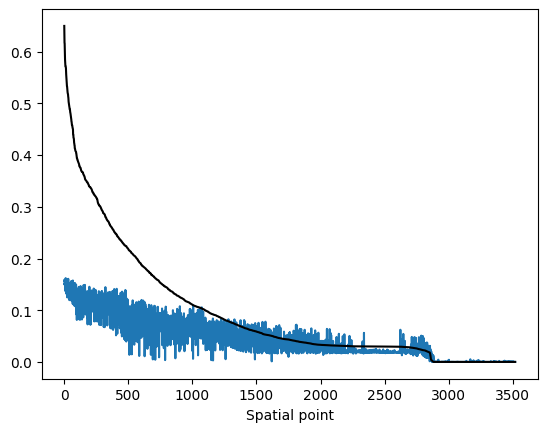

In [238]:
e_std_scaled_true = (dataset.e_std / dataset['g_ratio']).values.ravel()
e_std_scaled = (metrics.e_std.mean('ens') / dataset['g_ratio']).values.ravel()
idx = np.argsort(e_std_scaled_true)[::-1]
plt.plot(e_std_scaled[idx])
plt.plot(e_std_scaled_true[idx], color='k')
#plt.yscale('log')
#plt.xscale('log')
#plt.ylim([1e-2,1e0])
plt.xlabel('Spatial point')

In [157]:
np.linalg.norm(metrics.power_PCA_sqrt.mean('ens'))

3.782371

In [158]:
np.linalg.norm(dataset.power_PCA_sqrt)

8.821648884476227

In [142]:
metrics.e_mean_WSE_MAP

<xarray.DataArray 'e_mean_WSE_MAP' (zi: 2)> Size: 8B
array([76.35452, 82.80206], dtype=float32)
Coordinates:
    iter     int64 8B 0
  * zi       (zi) float64 16B 1.034e+03 1.036e+03

In [146]:
metrics.e_std_WSE_MAP

<xarray.DataArray 'e_std_WSE_MAP' (zi: 2)> Size: 8B
array([18.294008, 13.184763], dtype=float32)
Coordinates:
    iter     int64 8B 0
  * zi       (zi) float64 16B 1.034e+03 1.036e+03

In [150]:
metrics.e_std_WSE_MAP.sum()

<xarray.DataArray 'e_std_WSE_MAP' ()> Size: 4B
array(31.478771, dtype=float32)
Coordinates:
    iter     int64 8B 0

In [149]:
metrics.power_PCA_sqrt_WSE_MAP.sum()

<xarray.DataArray 'power_PCA_sqrt_WSE_MAP' ()> Size: 4B
array(31.72201, dtype=float32)
Coordinates:
    iter     int64 8B 0

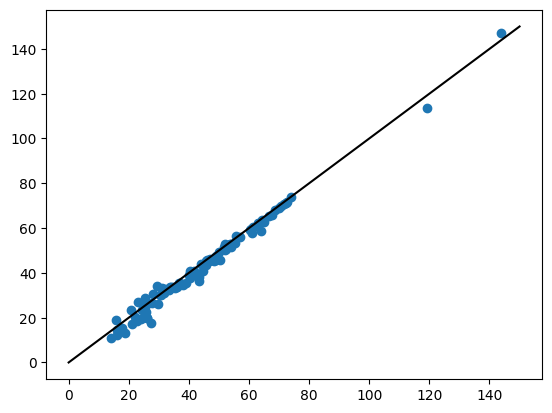

In [163]:
# Variance explained by PCA basis
plt.scatter(metrics.e_std_WSE.sum(['zi'], skipna=False), metrics.power_PCA_sqrt_WSE.sum(['PCA'], skipna=False))
plt.plot([0,150], [0,150], color='k')

# Why PCA loss function is exactly the same as interfaces standard deviation?
This would be possible if covariance matrix is already almost diagonal in the spatial coordinates.
Answer: covariance matrix is absolutely not diagonal

In [173]:
cov = 1/Nt * (X_true.T @ X_true)

In [184]:
cov_ssh = cov[:44*40,:44*40]

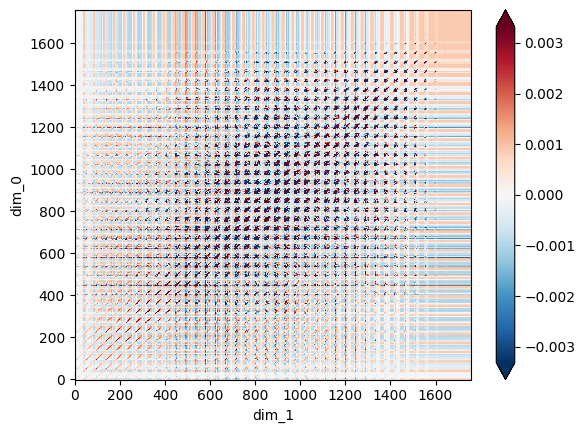

In [185]:
xr.DataArray(cov_ssh).plot.pcolormesh(robust=True)

In [187]:
np.linalg.norm(cov_ssh - np.diag(np.diag(cov_ssh))) / np.linalg.norm(cov_ssh)

0.9606969117777727

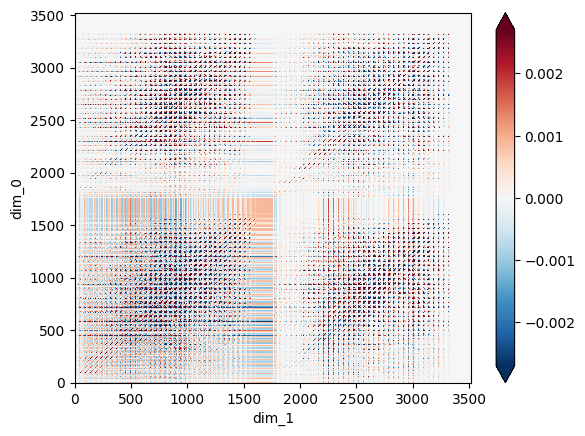

In [188]:
xr.DataArray(cov).plot.pcolormesh(robust=True)

In [189]:
np.linalg.norm(cov - np.diag(np.diag(cov))) / np.linalg.norm(cov)

0.9795339712440425

# What happend after the first iteration

In [37]:
metrics = xr.open_dataset('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_PCA_variability/metrics_06.nc').isel(iter=0).load()

In [ ]:
dataset=xr.open_dataset('../scripts/R32/R2_FGR3_PCA_variability3.nc').load()

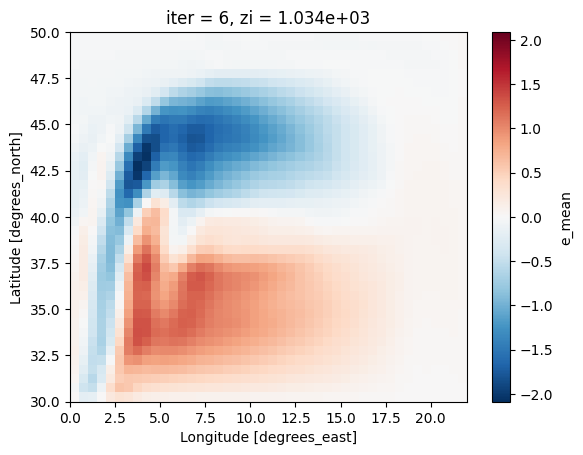

In [38]:
metrics.e_mean[-1][0].plot()

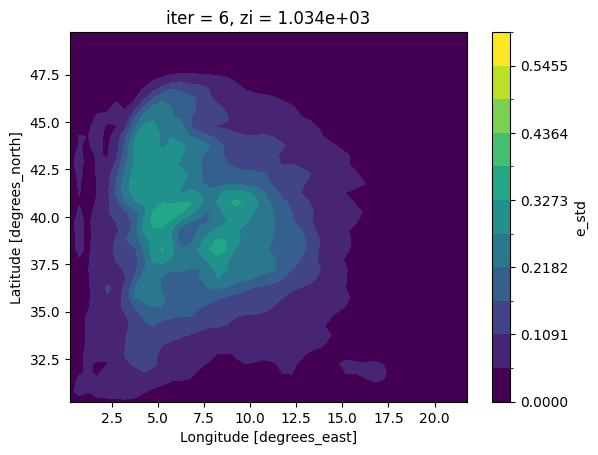

In [39]:
metrics.e_std[-1].isel(zi=0).plot.contourf(levels=np.linspace(0,0.6,12))

(0.0, 20.0)

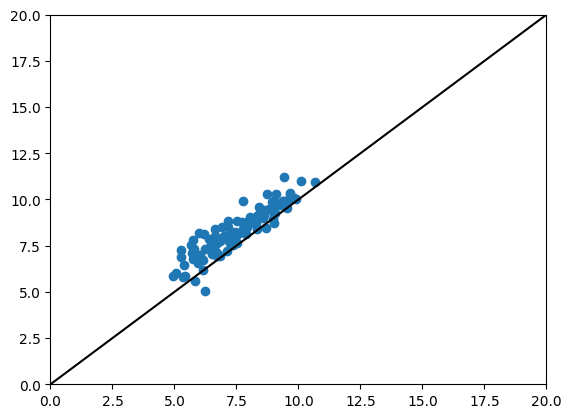

In [41]:
# Variance explained by PCA basis
plt.scatter(metrics.e_std_WSE.sum(['zi'], skipna=False), metrics.power_PCA_sqrt_WSE)
plt.plot([0,20], [0,20], color='k')
plt.xlim([0,20])
plt.ylim([0,20])

In [42]:
metrics.e_std_WSE_MAP.sum()

<xarray.DataArray 'e_std_WSE_MAP' ()> Size: 4B
array(6.2461815, dtype=float32)
Coordinates:
    iter     int64 8B 6

In [43]:
metrics.power_PCA_sqrt_WSE_MAP

<xarray.DataArray 'power_PCA_sqrt_WSE_MAP' ()> Size: 4B
array(7.432144, dtype=float32)
Coordinates:
    iter     int64 8B 6

Text(0, 0.5, 'Energy per EOF component \nof high-resolution model')

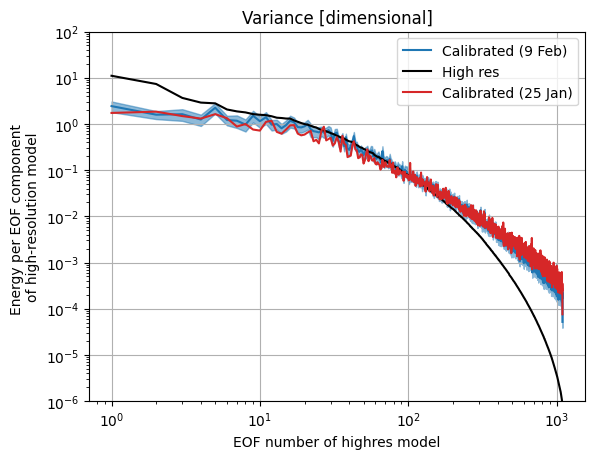

In [59]:
plt.plot(metrics.PCA+1, (metrics.power_PCA_sqrt**2).mean('ens'), label='Calibrated (9 Feb)')
plt.fill_between(metrics.PCA+1, (metrics.power_PCA_sqrt.mean('ens') - metrics.power_PCA_sqrt.std('ens'))**2,
            (metrics.power_PCA_sqrt.mean('ens') + metrics.power_PCA_sqrt.std('ens'))**2, color='tab:blue', alpha=0.5)
plt.plot(metrics.PCA+1, dataset.power_PCA_sqrt**2, color='k', label='High res')
plt.plot(metrics.PCA+1, Power_param, color='tab:red', label='Calibrated (25 Jan)')
plt.title('Variance [dimensional]')
plt.xlabel('EOF number of highres model')
plt.xscale('log')
#plt.yticks([0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0], [0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0])
plt.grid()
plt.legend()
plt.yscale('log')
plt.ylim([1e-6,1e+2])
plt.ylabel('Energy per EOF component \nof high-resolution model')

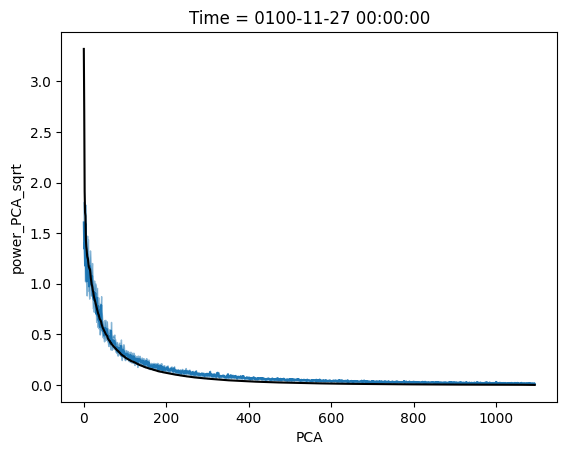

In [26]:
metrics.power_PCA_sqrt.mean('ens').plot()
plt.fill_between(metrics.PCA, metrics.power_PCA_sqrt.mean('ens') - metrics.power_PCA_sqrt.std('ens'),
            metrics.power_PCA_sqrt.mean('ens') + metrics.power_PCA_sqrt.std('ens'), color='tab:blue', alpha=0.5)
dataset.power_PCA_sqrt.plot(color='k')
#plt.yscale('log')
#plt.xscale('log')
#plt.ylim([1e-3,1e+1])

# Further work on normalization constants
Long goal: We would like to have equal contribution for mean and variability if we consider the state of rest ocean


Now we need two normalizations. Let $y$ be non-normalized interface. We first make equal contribution of layers with g_prime:
$$
y' = y / g\_ratio
$$
Second, we introduce normalize state of rest
$$
rest' = rest / g\_ratio
$$
Finally, we divide the vector by l2 norm of distance to the rest:
$$
y'' = y' / ||y'-rest'||_2
$$
We now express the final vector through the initial one:
$$
y'' = y / (g\_ratio * ||y / g\_ratio - rest / g\_ratio||_2)
$$
And final normalization constant is:
$$
\Gamma = g\_ratio^2 * ||(y - rest) / g\_ratio||_2^2
$$
Note: g_ratio does not contract simply because we compute second norm over two dimensions

In [4]:
dataset = xr.open_dataset('../scripts/R32/R2_FGR3_PCA_variability.nc').load()

In [17]:
e_mean_rest = xr.DataArray([0., -1000.], dims='zi')
e_mean_rest = np.maximum(e_mean_rest, ds['R32_R2_FGR3'].e.isel(zi=2,Time=-1).drop_vars('zi'))
e_std_rest = xr.DataArray([0., 0.], dims='zi')
power_PCA_sqrt_rest = dataset['power_PCA_sqrt'] * 0

In [6]:
g_ratio = xr.DataArray([1., 100.], dims='zi')
dataset['e_mean_var_PCA2'] = g_ratio**2 * (((dataset['e_mean'] - e_mean_rest) / g_ratio)**2).sum() + 0*dataset['e_mean']
dataset['e_std_var_PCA2']  = g_ratio**2 * (((dataset['e_std']  - e_std_rest) / g_ratio)**2).sum() + 0*dataset['e_std']

In [18]:
# Here we normalize simply by second norm because but not g_prime, because g_prime was already used to extract PCAs
dataset['power_PCA_sqrt_var2'] = (((dataset['power_PCA_sqrt'] - power_PCA_sqrt_rest))**2).sum() + 0*dataset['power_PCA_sqrt']

In [7]:
np.unique(dataset['e_mean_var_PCA2']) / np.unique(dataset['e_std_var_PCA2'])

array([14.58654527, 14.58654527])

In [8]:
np.unique(dataset['e_mean_var_PCA']) / np.unique(dataset['e_std_var_PCA'])

array([1., 1.], dtype=float32)

In [11]:
# Sanity check. Normalization is pretty similar to what we had before
np.unique(dataset['e_mean_var_loss']) / np.unique(dataset['e_std_var_loss'])

array([12.600231, 19.749174], dtype=float32)

In [13]:
np.unique(dataset['e_mean_var_PCA2'])

array([1.13514667e+03, 1.13514667e+07])

In [14]:
np.unique(dataset['e_mean_var_loss'])

array([5.696610e+02, 6.440428e+06], dtype=float32)

In [16]:
# Approximately two, because now we treat full interface vector as a whole
np.unique(dataset['e_mean_var_PCA2']).sum() / np.unique(dataset['e_mean_var_loss']).sum()

1.762553372507145

In [20]:
# Check consistency of normalization of std and power spectrum

In [24]:
np.linalg.norm(dataset['e_std'] / np.sqrt(dataset['e_std_var_PCA2']))

0.9999999999999999

In [25]:
np.linalg.norm(dataset['power_PCA_sqrt'] / np.sqrt(dataset['power_PCA_sqrt_var2']))

1.0

In [26]:
np.linalg.norm((dataset['e_mean'] - e_mean_rest) / np.sqrt(dataset['e_mean_var_PCA2']))

1.0

In [27]:
dataset.astype('float32').to_netcdf('../scripts/R32/R2_FGR3_PCA_variability2.nc')

# Compute PCAs for the noise model

In [15]:
dataset = xr.open_dataset('../scripts/R32/R2_FGR3_PCA_variability2.nc').load()

In [3]:
metrics = xr.open_dataset('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/noise_model/metrics_00.nc').load()

In [6]:
sys.path.append('../calibration_driver/helpers/')

In [8]:
from metrics_DG import return_climate_metrics

In [14]:
exp_path = [f'/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/noise_model/iteration-00/ens-member-{ens:02}/output' for ens in range(1000)]

In [29]:
metrics['power_PCA_sqrt'] = xr.DataArray(np.nan * np.ones((1, 1000,1095)), dims=['iter', 'ens', 'PCA'])
for ens, path in zip(range(1000), exp_path):
    metrics['power_PCA_sqrt'].data[0][ens] = return_climate_metrics(path, 3650., 7300., dataset, "power_PCA_sqrt")["power_PCA_sqrt"]
    print(ens, path)

(1e-06, 100.0)

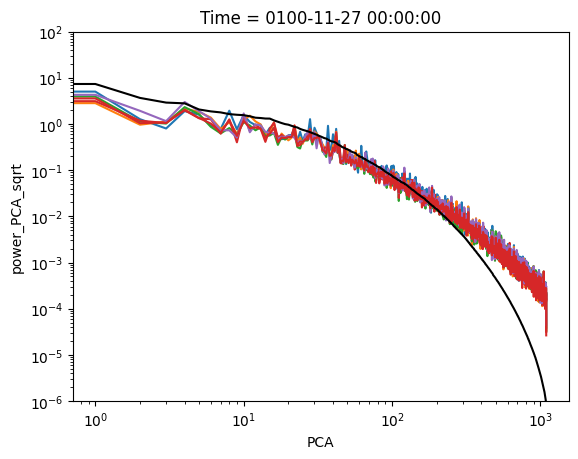

In [33]:
for idx in np.random.choice(1000,5):
    (metrics['power_PCA_sqrt'][0][idx]**2).plot()

(metrics['power_PCA_sqrt'].mean('ens')**2).plot(color='tab:red')

(dataset.power_PCA_sqrt**2).plot(color='k')
plt.yscale('log')
plt.xscale('log')
plt.ylim([1e-6,1e+2])

In [34]:
metrics.to_netcdf('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/noise_model/metrics_00.nc')

# Full covariance matrix

In [183]:
metrics = xr.open_dataset('../scripts/R32/R2_FGR3_PCA_variability2.nc').load()

In [189]:
X_true = interfaces_scaled.values.reshape(Nt,-1)
cov = 1./Nt *(X_true.T@X_true)

In [190]:
cov.shape

(3520, 3520)

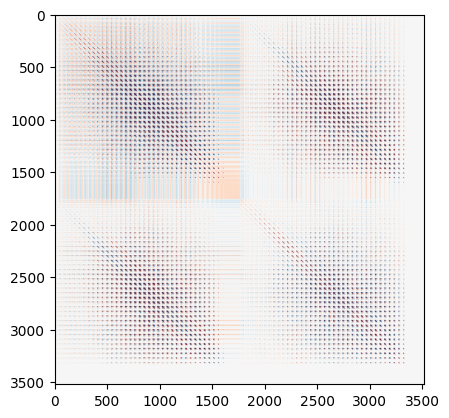

In [191]:
plt.imshow(cov, vmin=-cov.std(), vmax=cov.std(),cmap='RdBu_r')

In [192]:
metrics['covariance_matrix'] = xr.DataArray(cov, dims=['NzNyNx_dummy', 'NzNyNx'])

In [193]:
metrics['covariance_matrix_var'] = 1. + 0 * metrics['covariance_matrix']

In [195]:
X_true_4 = interfaces_scaled.coarsen({'xh':4, 'yh':4}).mean().values.reshape(Nt,-1)
cov_4 = 1./Nt *(X_true_4.T@X_true_4)

In [202]:
np.linalg.norm(X_true_4.mean(0))

1.120542088975968e-15

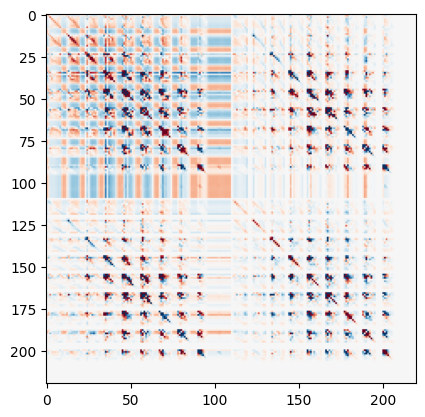

In [197]:
plt.imshow(cov_4, vmin=-cov_4.std(), vmax=cov_4.std(),cmap='RdBu_r')

In [198]:
metrics['covariance_matrix_4'] = xr.DataArray(cov_4, dims=['NzNyNx_dummy_4', 'NzNyNx_4'])

In [199]:
metrics['covariance_matrix_4_var'] = 1. + 0 * metrics['covariance_matrix_4']

In [200]:
metrics.astype('float64').to_netcdf('../scripts/R32/R2_FGR3_PCA_variability3.nc')

# Check prediction

In [2]:
dataset=xr.open_dataset('../scripts/R32/R2_FGR3_PCA_variability3.nc').load()

In [3]:
metrics = xr.open_dataset('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_PCA_variability3/metrics_00.nc')

Text(0.5, 1.0, 'Covariance matrix in initial ensemble')

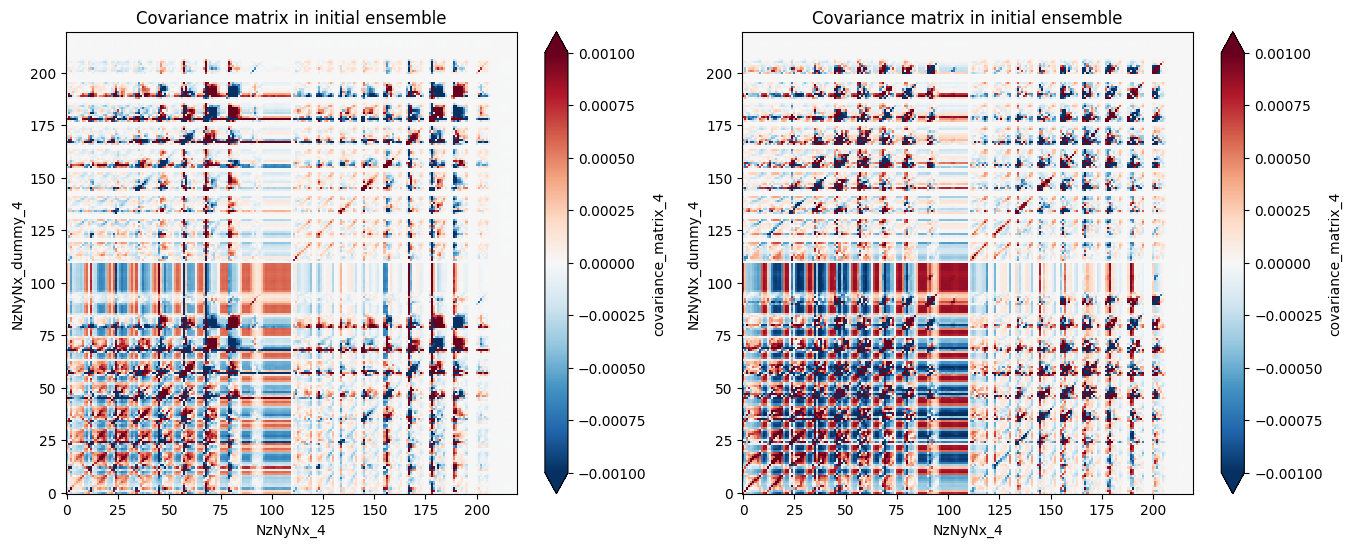

In [16]:
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
metrics.covariance_matrix_4.isel(iter=0).isel(ens=10).plot(vmin=-0.001)
plt.title('Covariance matrix in initial ensemble')

plt.subplot(1,2,2)
dataset.covariance_matrix_4.plot(vmin=-0.001)
plt.title('Covariance matrix in initial ensemble')